## SME0823 - Modelos de Regressão e Aprendizado Supervisionado II

### **Yuri Fernandes Pereira - 13730127**

### Avaliação 2

#### Entrega até 1/12/2025, individual.

#### Forma de entrega:

O/a aluno/a deve fazer o upload do notebook executado em um repositório github público, indicando seu nome completo e código da disciplina, e indicar link do notebook no e-disciplinas em local que será indicado.

Um estudo clínico busca investigar fatores associados ao número de espirros diários apresentados por indivíduos com rinite alérgica no período em que as plantas mais liberam o pólen no ar. Para cada participante, foram coletadas as seguintes variáveis:

* **nsneeze**: número de espirros observados em um dia (variável resposta de contagem).
* **alcohol**: consumo de bebida alcoólica nas 24 horas anteriores (0 = não, 1 = sim).
* **antihist**: uso de anti-histamínico no dia da observação (0 = não, 1 = sim).
* **smoker**: indicador de tabagismo (0 = não fumante, 1 = fumante).
* **age**: idade do paciente (anos).
* **pollen**: índice quantitativo de concentração de pólen no ar no dia da observação.


**1.** Desenvolva uma breve análise exploratória dos dados e avalie as primeiras impressões sobre a associação entre a variável **nsneeze** e as demais.

**2.** Ajuste um modelo de Poisson para explicar **nsneeze** em função das covariáveis
**alcohol**, **antihist**, **smoker**, **age** e **pollen**. Não é necessário incluir interações.

Apresente e interprete:

* a estimativa dos coeficientes,
* sua significância estatística.

**3.** Verifique se há indícios de superdispersão no modelo de Poisson ajustado no item 2 por, pelo menos, dois métodos diferentes.

Interprete os resultados e conclua se o modelo de Poisson é adequado em termos de dispersão.


**4.** Caso seja detectada superdispersão, ajuste um modelo **Binomial Negativo** com a mesma estrutura de regressão do item 2. Compare os ajustes de Poisson e Binomial Negativa por meio de:

* desvio (deviance),
* AIC,
* gráficos de resíduos componentes do desvio.

Discuta qual modelo é mais adequado para descrever o número de espirros, justificando sua resposta com base nas métricas e nos diagnósticos gráficos.


**5.** Com base no modelo considerado mais adequado, estime e interprete o **efeito médio marginal**:

* do consumo de álcool (**alcohol**) sobre o número médio de espirros,
* do uso de anti-histamínico (**antihist**).


**6.** Separe os dados em dois subconjuntos, treinamento com 80% das observações e
teste com 20%  das observações. Com base apenas no conjunto de treinamento, ajuste os modelos Poisson e Binomial Negativo com a mesma estrutura de covariáveis dos itens anteriores. No conjunto de teste, calcule, para cada modelo:

* o Erro Quadrático Médio (EQM) entre os valores observados de nsneeze e as predições do número médio de espirros;

* o Erro Absoluto Médio (EAM).

Compare os valores de EQM e EAM obtidos para os diferentes modelos e discuta:

qual deles apresenta melhor desempenho preditivo fora da amostra;

em que medida as conclusões baseadas em critérios de ajuste (deviance, AIC) coincidem ou não com aquelas baseadas nas medidas de desempenho preditivo (EQM e EAM).


**7.** Utilizando o modelo escolhido por você, faça previsões do número **esperado** de espirros para os seguintes perfis:

1. Indivíduo A:

   * alcohol = 0,
   * antihist = 1,
   * smoker = 0,
   * age = 30 anos,
   * pollen = valor correspondente a um dia de baixa concentração.

2. Indivíduo B:

   * alcohol = 1,
   * antihist = 0,
   * smoker = 1,
   * age = 50 anos,
   * pollen = valor correspondente a um dia de alta concentração.


Utilize os códigos abaixo para iniciar suas análises.

Atenção: Se seu número USP

- termina com 0 ou 1, utilize os dados sneeze1
- termina com 2 ou 3, utilize os dados sneeze2
- termina com 4 ou 5, utilize os dados sneeze3
- termina com 6 ou 7, utilize os dados sneeze4
- termina com 8 ou 9, utilize os dados sneeze5

## **1.**
Desenvolva uma breve análise exploratória dos dados e avalie as primeiras impressões sobre a associação entre a variável **nsneeze** e as demais.


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

df = pd.read_csv('https://raw.githubusercontent.com/yurifernandes96/SME0823/refs/heads/main/sneeze4.csv')
df = df.iloc[:, 1:]

df

,nsneeze,alcohol,antihist,smoker,age,pollen
0,7,0,0,0,32.0,51.467099
1,10,1,0,0,18.0,56.430551
2,16,0,0,0,24.0,68.442015
3,3,0,1,0,20.0,36.114753
4,27,0,0,0,52.0,64.221487
...,...,...,...,...,...,...
1595,1,0,1,0,18.0,20.829811
1596,21,1,0,0,29.0,56.559262
1597,9,0,1,1,29.0,61.302369
1598,12,1,0,0,48.0,53.128366


In [30]:
df.columns

Index(['nsneeze', 'alcohol', 'antihist', 'smoker', 'age', 'pollen'], dtype='object')

In [31]:
df.describe()

,nsneeze,alcohol,antihist,smoker,age,pollen
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,44.586875,0.405000,0.242500,0.193750,32.138750,59.142035
std,143.814421,0.491046,0.428729,0.395359,12.000813,29.653766
min,0.000000,0.000000,0.000000,0.000000,18.000000,4.673025
25%,9.000000,0.000000,0.000000,0.000000,21.000000,37.331341
50%,18.000000,0.000000,0.000000,0.000000,31.000000,54.643810
75%,38.000000,1.000000,0.000000,0.000000,40.000000,74.703597
max,3897.000000,1.000000,1.000000,1.000000,74.000000,201.994822


### Histograma da variável resposta

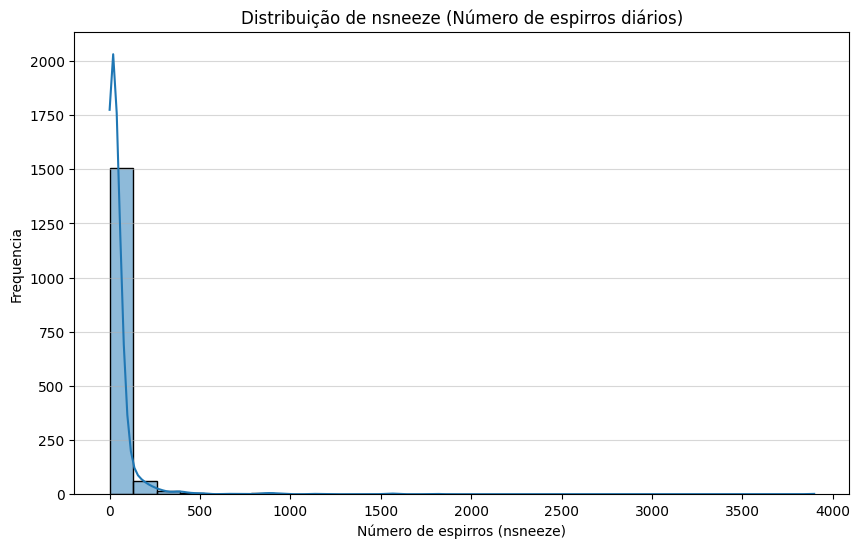

In [32]:
# Histograma da variável resposta
plt.figure(figsize=(10, 6))
sns.histplot(df['nsneeze'], bins=30, kde=True)
plt.title('Distribuição de nsneeze (Número de espirros diários)')
plt.xlabel('Número de espirros (nsneeze)')
plt.ylabel('Frequencia')
plt.grid(axis='y', alpha=0.5)
plt.show()

A variável resposta apresenta uma distribuição altamente assimétrica à direita, com uma mediana ($\approx 18$) muito menor que a média ($\approx 44.6$), e um valor máximo extremo ($\approx 3897$). Isso é característico de dados de contagem. O modelo estatístico adequado para essa variável deve levar em conta a assimetria e a variação, como os Modelos de Regressão de Poisson ou Binomial Negativa.

### Associação com as variáveis categóricas

In [33]:
# Value Counts das variáveis categóricas
print("\nValue Counts alcohol:")
print(df['alcohol'].value_counts(normalize=True))
print("\nValue Counts antihist:")
print(df['antihist'].value_counts(normalize=True))
print("\nValue Counts smoker:")
print(df['smoker'].value_counts(normalize=True))


Value Counts alcohol:
alcohol
0    0.595
1    0.405
Name: proportion, dtype: float64

Value Counts antihist:
antihist
0    0.7575
1    0.2425
Name: proportion, dtype: float64

Value Counts smoker:
smoker
0    0.80625
1    0.19375
Name: proportion, dtype: float64


A distribuição das variáveis categoricas é:


*   alcohol (Consumo de Álcool): $40.5\%$ dos indivíduos consumiram álcool.
*   antihist (Uso de Anti-histamínico): $24.3\%$ dos indivíduos usaram anti-histamínico.
*   smoker (Tabagismo): $19.4\%$ dos indivíduos são fumantes.

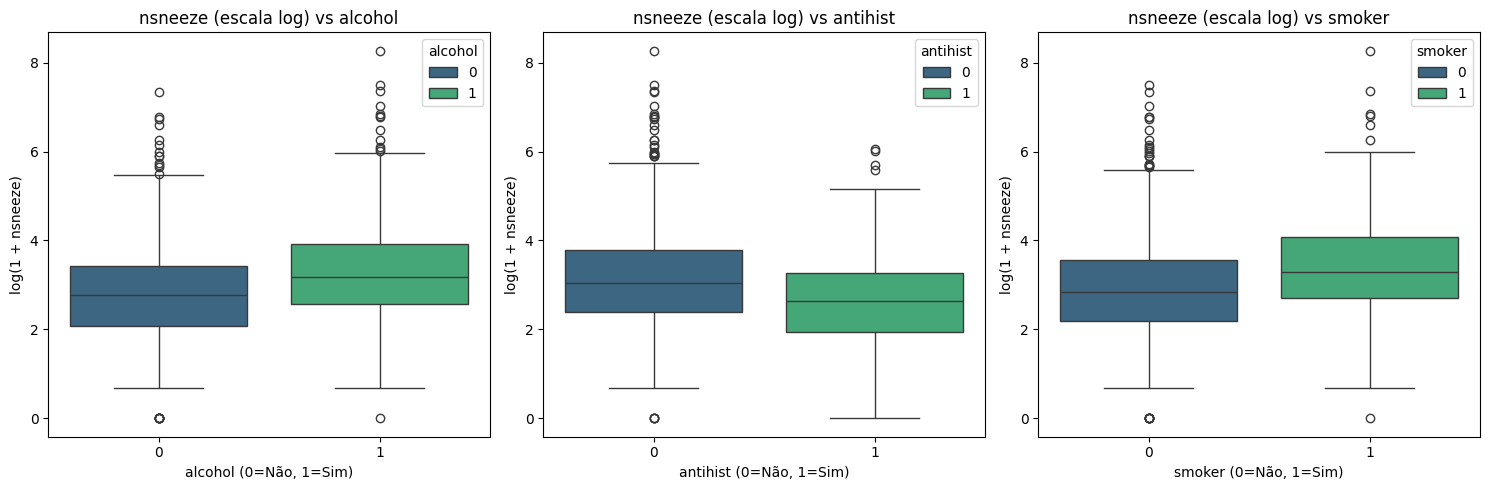

In [34]:
# Box plots nsneeze vs categóricas
# (usando escala log para melhor visualização devido à outliers extremos)

df['nsneeze_log'] = np.log1p(df['nsneeze'])

vars_categoricas = ['alcohol', 'antihist', 'smoker']

plt.figure(figsize=(15, 5))

for i, var in enumerate(vars_categoricas):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=var, y='nsneeze_log', data=df, hue=var, palette='viridis')
    plt.title(f'nsneeze (escala log) vs {var}')
    plt.xlabel(f'{var} (0=Não, 1=Sim)')
    plt.ylabel('log(1 + nsneeze)')

plt.tight_layout()
plt.show()

Os box_plots (utilizando uma transformação logarítmica de nsneeze para visualização) indicam que:

*   O consumo de álcool está associado a um maior número de espirros.
*   O uso de anti-histamínico está associado a um menor número de espirros, como esperado.
*   O tabagismo está associado a um maior número de espirros.



### Associação com variáveis contínuas

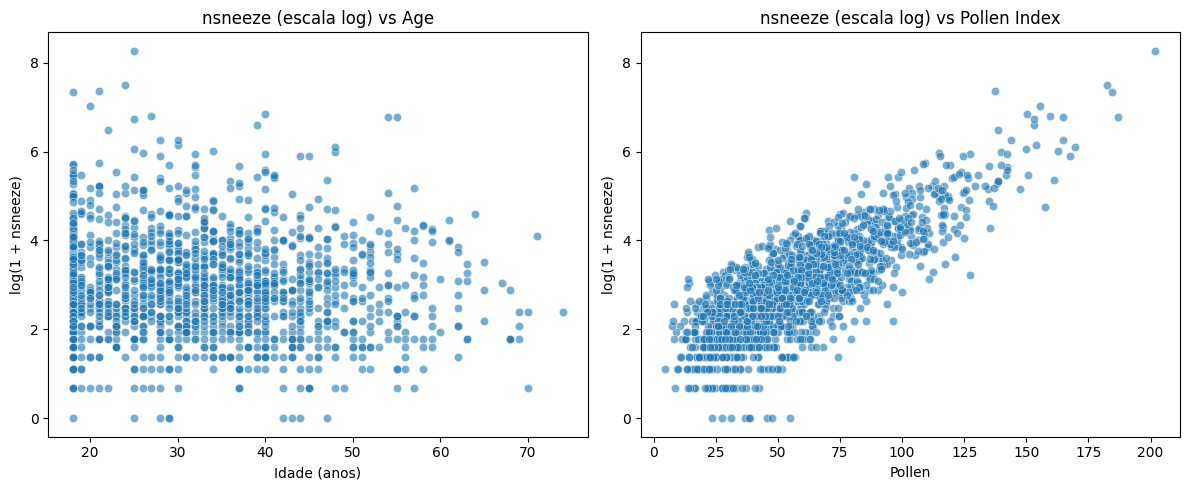

In [35]:
# nsneeze vs age e nsneeze vs pollen

# Scatter plots (usando escala log para nsneeze)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x='age', y='nsneeze_log', data=df, alpha=0.6)
plt.title('nsneeze (escala log) vs Age')
plt.xlabel('Idade (anos)')
plt.ylabel('log(1 + nsneeze)')

plt.subplot(1, 2, 2)
sns.scatterplot(x='pollen', y='nsneeze_log', data=df, alpha=0.6)
plt.title('nsneeze (escala log) vs Pollen Index')
plt.xlabel('Pollen')
plt.ylabel('log(1 + nsneeze)')

plt.tight_layout()
plt.show()

Os scatter plots (utilizando uma transformação logarítmica de nsneeze para visualização) indicam que:

*   O gráfico de dispersão de nsneeze versus Pólen mostra que, à medida que a concentração de pólen aumenta, o número de espirros tende a aumentar.
*   O gráfico de dispersão de nsneeze versus Idade não mostra um padrão claro, indicando uma fraca correlação.

### Correlação de Pearson

In [36]:
df.drop(columns=['nsneeze_log'], inplace=True)

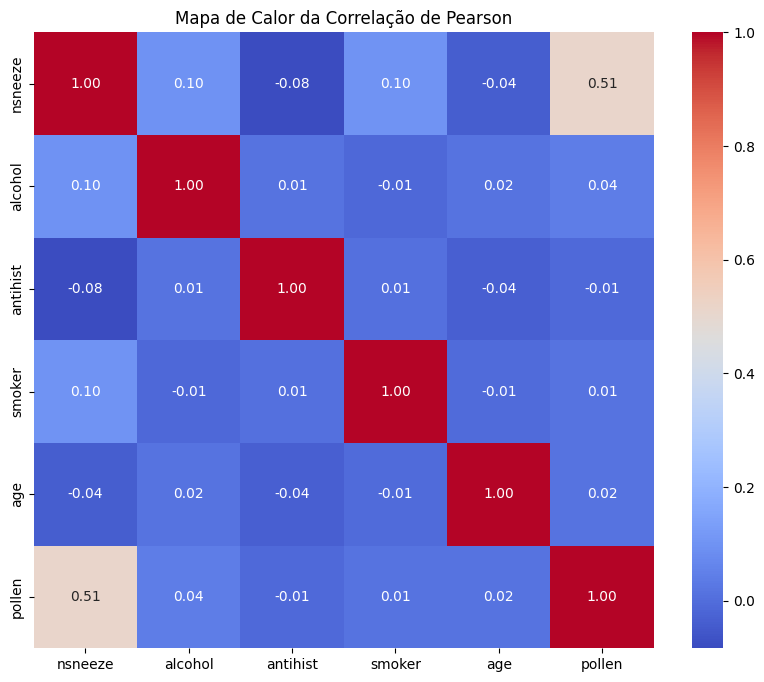

In [37]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de Calor da Correlação de Pearson')
plt.show()

### Conclusão inicial

As primeiras impressões sugerem que:

*   Pólen é o preditor contínuo com a associação mais forte e positiva com o número de espirros.

*   O consumo de álcool e o tabagismo parecem estar associados a um aumento no número de espirros.

*   O uso de anti-histamínico está associado a uma redução no número de espirros.

*   A idade tem uma associação linear muito fraca com o número de espirros.

## **2.**
Ajuste um modelo de Poisson para explicar **nsneeze** em função das covariáveis
**alcohol**, **antihist**, **smoker**, **age** e **pollen**. Não é necessário incluir interações.

Apresente e interprete:

* a estimativa dos coeficientes,
* sua significância estatística.


In [38]:
resposta = df['nsneeze']
preditoras = df[['alcohol', 'antihist', 'smoker', 'age', 'pollen']]

In [39]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [40]:
formula = "nsneeze ~ C(alcohol) + C(antihist) + C(smoker) + age + pollen"

modelo_pois = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.Poisson()
)

ajuste_pois = modelo_pois.fit()
print(ajuste_pois.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                nsneeze   No. Observations:                 1600
Model:                            GLM   Df Residuals:                     1594
Model Family:                 Poisson   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11346.
Date:                Mon, 01 Dec 2025   Deviance:                       15064.
Time:                        03:55:16   Pearson chi2:                 1.59e+04
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.5002      0.015  

In [41]:
# Prepara a tabela de resultados para interpretação (coeficientes, p-valores, Razão de Taxas)
tabela_resultados = pd.DataFrame({
    'Coeficiente (Beta)': ajuste_pois.params,
    'Std. Error': ajuste_pois.bse,
    'p-valor': ajuste_pois.pvalues,
    'RR (exp(Beta))': np.exp(ajuste_pois.params)
})

# Filter out the intercept for easier interpretation, but include it in the output
tabela_resultados = tabela_resultados.rename(index={'Intercept': 'Intercepto'})
print("\nTabela de coeficientes, p-valores, e razão de taxas (rate ratio):\n")
print(tabela_resultados)


Tabela de coeficientes, p-valores, e razão de taxas (rate ratio):

                  Coeficiente (Beta)  Std. Error        p-valor  RR (exp(Beta))
Intercepto                  1.500231    0.014661   0.000000e+00        4.482727
C(alcohol)[T.1]             0.443938    0.007651   0.000000e+00        1.558833
C(antihist)[T.1]           -0.611652    0.011338   0.000000e+00        0.542454
C(smoker)[T.1]              0.427718    0.008206   0.000000e+00        1.533754
age                        -0.012685    0.000343  9.570250e-300        0.987395
pollen                      0.031389    0.000081   0.000000e+00        1.031887


Todos os preditores incluídos no modelo apresentaram **significância estatística** (p-valor $< 0.001$), indicando que cada variável está associada de forma significativa ao número de espirros diários, controlando-se pelas demais variáveis.

*   alcohol (Consumo de Álcool): $\text{RR} = 1.56$.
Indivíduos que consumiram álcool (alcohol = 1) têm uma taxa esperada de espirros $1.56$ vezes maior, ou seja, $56\%$ a mais, em comparação com aqueles que não consumiram álcool (alcohol = 0), mantendo as demais variáveis constantes.

*   antihist (Uso de Anti-histamínico): $\text{RR} = 0.54$. Indivíduos que usaram anti-histamínico (antihist = 1) têm uma taxa esperada de espirros $0.54$ vezes a taxa de quem não usou, o que representa uma redução de aproximadamente $46\%$, mantendo as demais variáveis constantes.

*   smoker (Tabagismo): $\text{RR} = 1.53$. Fumantes (smoker = 1) têm uma taxa esperada de espirros $1.53$ vezes maior, ou seja, $53\%$ a mais, em comparação com não-fumantes (smoker = 0), mantendo as demais variáveis constantes.


*   pollen (Índice de Pólen): $\text{RR} = 1.03$. Para cada aumento de $1$ unidade no índice de pólen, a taxa esperada de espirros aumenta por um fator de $1.03$, o que corresponde a um aumento de aproximadamente $3.2\%$ no número de espirros ($1.0318 - 1$), mantendo as demais variáveis constantes.


*   age (Idade): $\text{RR} = 0.99$. Para cada aumento de $1$ ano na idade, a taxa esperada de espirros é multiplicada por $0.99$, o que corresponde a uma redução muito pequena de aproximadamente $1.3\%$ ($1 - 0.987$) no número de espirros, mantendo as demais variáveis constantes.

## **3.**
Verifique se há indícios de superdispersão no modelo de Poisson ajustado no item 2 por, pelo menos, dois métodos diferentes. Interprete os resultados e conclua se o modelo de Poisson é adequado em termos de dispersão.


In [42]:
# Extrai estatísticas necessárias
dev = ajuste_pois.deviance
chi2_pearson = ajuste_pois.pearson_chi2
df_res = ajuste_pois.df_resid

print(f"Deviance: {dev:.2f}")
print(f"Chi-quadrado de Pearson: {chi2_pearson:.2f}")
print(f"Graus de liberdade residuais: {df_res}")

Deviance: 15063.68
Chi-quadrado de Pearson: 15915.95
Graus de liberdade residuais: 1594


In [43]:
# Método 1: Razão entre as Estatísticas de Dispersão e os Graus de Liberdade

# Fator de Dispersão baseado na Deviance
dispersion_deviance = dev / df_res

# Fator de Dispersão baseado no Chi-quadrado de Pearson
dispersion_pearson = chi2_pearson / df_res

print("\n--- Método 1: Fatores de Dispersão Estimados ---")
print(f"Fator de Dispersão (Deviance / DfRes): {dispersion_deviance:.4f}")
print(f"Fator de Dispersão (Pearson Chi2 / DfRes): {dispersion_pearson:.4f}")


--- Método 1: Fatores de Dispersão Estimados ---
Fator de Dispersão (Deviance / DfRes): 9.4502
Fator de Dispersão (Pearson Chi2 / DfRes): 9.9849


O modelo de Poisson assume que a média ($\mu$) da variável resposta é igual à sua variância ($\sigma^2$), ou seja, $\text{E}(\text{nsneeze}) = \text{Var}(\text{nsneeze})$.

A superdispersão ocorre quando a variância é significativamente maior que a média ($\text{Var}(\text{nsneeze}) > \text{E}(\text{nsneeze})$).

O fator de dispersão estimado ($\hat{\phi}$) é a razão entre a estatística de dispersão (Deviance ou Qui-quadrado de Pearson) e os graus de liberdade residuais ($DF_{Res} = 1594$). Se o modelo de Poisson for adequado, $\hat{\phi}$ deve ser próximo de $1$.

Ambos os fatores de dispersão ($\hat{\phi} \approx 9.5$ e $\approx 10.0$) são muito maiores que $1$. Isso indica que a variância observada no número de espirros é cerca de $9$ a $10$ vezes maior do que o previsto pelo modelo de Poisson.

In [44]:
# Método 2: envelope de resíduos

def envelope_poisson(fitted_model, X, title):
    resid_dev = fitted_model.resid_deviance.copy()
    sorted_resid = np.sort(resid_dev)

    sim_resid = []
    for _ in range(100):
        mu_sim = np.clip(fitted_model.fittedvalues, 1e-3, 1e5)
        y_sim = np.random.poisson(mu_sim)
        sim_model = sm.GLM(y_sim, X, family=sm.families.Poisson()).fit()
        sim_resid.append(np.sort(sim_model.resid_deviance))

    sim_resid = np.array(sim_resid)
    lower = np.percentile(sim_resid, 2.5, axis=0)
    upper = np.percentile(sim_resid, 97.5, axis=0)

    plt.plot(sorted_resid, 'o', label="Resíduos observados")
    plt.plot(lower, 'r--', linewidth=1, label="banda 2.5%")
    plt.plot(upper, 'r--', linewidth=1, label="banda 97.5%")
    plt.title(title)
    plt.xlabel("Ordem dos resíduos")
    plt.ylabel("Resíduo componente do desvio")
    plt.legend()
    plt.grid(True)

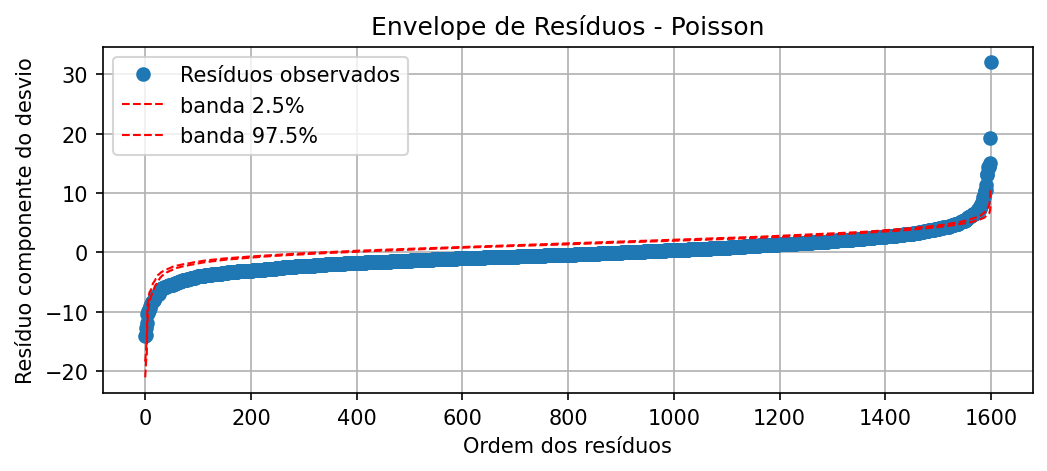

In [45]:
results = ajuste_pois
X = preditoras
plt.figure(figsize=(8, 3), dpi=150)
envelope_poisson(results, X, "Envelope de Resíduos - Poisson")

A maioria dos pontos de resíduo estão fora do que seria o intervalo esperado para um modelo de Poisson bem ajustado. Este espalhamento excessivo significa que a variância residual é muito maior do que a assumida pela distribuição de Poisson (onde a $\text{Variância} = \text{Média}$).

O gráfico demonstra claramente que o Modelo de Poisson subestima drasticamente a variabilidade real do número de espirros (nsneeze). A alta variância dos resíduos é a representação visual da superdispersão.

### Implicações da superdirspersão no modelo de Poisson

A presença da superdispersão, confirmada pelo fator de dispersão ($\hat{\phi} \approx 10$) e pelo gráfico de resíduos, implica que as conclusões do modelo de Poisson são comprometidas:
*   Erros Padrão Inflacionados: Os erros padrão dos coeficientes foram subestimados, e os valores $P$ são falsamente baixos, levando a conclusões incorretas de significância estatística.
*   A distribuição de Poisson é inadequada para este dataset.

## **4.**
Caso seja detectada superdispersão, ajuste um modelo **Binomial Negativo** com a mesma estrutura de regressão do item 2. Compare os ajustes de Poisson e Binomial Negativa por meio de:

* desvio (deviance),
* AIC,
* gráficos de resíduos componentes do desvio.

Discuta qual modelo é mais adequado para descrever o número de espirros, justificando sua resposta com base nas métricas e nos diagnósticos gráficos.


In [46]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = "nsneeze ~ C(alcohol) + C(antihist) + C(smoker) + age + pollen"

alpha_fixado = 0.2

#alpha para sneeze1 a sneeze5 = 0.23, 0.3, 0.25,  0.2, 0.2

modelo_nb = smf.glm(
    formula=formula,
    data=df,
    family=sm.families.NegativeBinomial(alpha=alpha_fixado)
)

ajuste_nb = modelo_nb.fit()
print(ajuste_nb.summary())

alpha_usado = ajuste_nb.family.alpha
print("Alpha usado no modelo:", alpha_usado)

alpha_est = ajuste_nb.params.iloc[-1]
print("Alpha estimado:", alpha_est)


                 Generalized Linear Model Regression Results                  
Dep. Variable:                nsneeze   No. Observations:                 1600
Model:                            GLM   Df Residuals:                     1594
Model Family:        NegativeBinomial   Df Model:                            5
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -6055.7
Date:                Mon, 01 Dec 2025   Deviance:                       1785.6
Time:                        03:55:17   Pearson chi2:                 1.71e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9981
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            1.4703      0.047  

In [47]:
# Comparação de métricas
metricas = pd.DataFrame({
    'Poisson': {
        'Deviance': ajuste_pois.deviance,
        'AIC': ajuste_pois.aic,
        'Log-Likelihood': ajuste_pois.llf,
        'GL Residuos': ajuste_pois.df_resid
    },
    'Binomial Negativa': {
        'Deviance': ajuste_nb.deviance,
        'AIC': ajuste_nb.aic,
        'Log-Likelihood': ajuste_nb.llf,
        'GL Residuos': ajuste_nb.df_resid
    }
})

print("--- Comparação de Métricas de Ajuste ---\n")
print(metricas.T)

--- Comparação de Métricas de Ajuste ---

                       Deviance           AIC  Log-Likelihood  GL Residuos
Poisson            15063.680202  22704.144884   -11346.072442       1594.0
Binomial Negativa   1785.642229  12123.499133    -6055.749566       1594.0


O modelo de Poisson apresentou um Desvio extremamente alto ($15063.68$), que era a principal indicação de superdispersão, pois era $\approx 9.5$ vezes maior que os graus de liberdade residuais ($1594$). O modelo Binomial Negativa reduziu o Desvio drasticamente para $1785.64$. Este valor é mais próximo dos graus de liberdade residuais, indicando que o modelo Binomial Negativa resolve o problema de superdispersão.

A grande redução no AIC ($22704.14$ para $12123.50$) indica que o modelo Binomial Negativa é muito superior em termos de poder preditivo.

In [48]:
def envelope_negbin(fitted_model, title):
    # resíduos observados
    resid_dev = fitted_model.resid_deviance.copy()
    sorted_resid = np.sort(resid_dev)

    # matriz de design e parâmetros do próprio modelo
    X = fitted_model.model.exog
    mu = np.clip(fitted_model.fittedvalues, 1e-3, 1e5)
    alpha = fitted_model.family.alpha

    sim_resid = []
    for _ in range(100):
        # simula Y ~ NB(mu, alpha) com a mesma parametrização
        n_sim = 1 / alpha
        p_sim = n_sim / (n_sim + mu)
        y_sim = np.random.negative_binomial(n=n_sim, p=p_sim)

        sim_model = sm.GLM(
            y_sim,
            X,
            family=sm.families.NegativeBinomial(alpha=alpha)
        ).fit()

        sim_resid.append(np.sort(sim_model.resid_deviance))

    sim_resid = np.array(sim_resid)
    lower = np.percentile(sim_resid, 2.5, axis=0)
    upper = np.percentile(sim_resid, 97.5, axis=0)

    plt.plot(sorted_resid, "o", label="Resíduos observados")
    plt.plot(lower, "r--", linewidth=1, label="banda 2.5%")
    plt.plot(upper, "r--", linewidth=1, label="banda 97.5%")
    plt.title(title)
    plt.xlabel("Ordem dos resíduos")
    plt.ylabel("Resíduo componente do desvio")
    plt.legend()
    plt.grid(True)


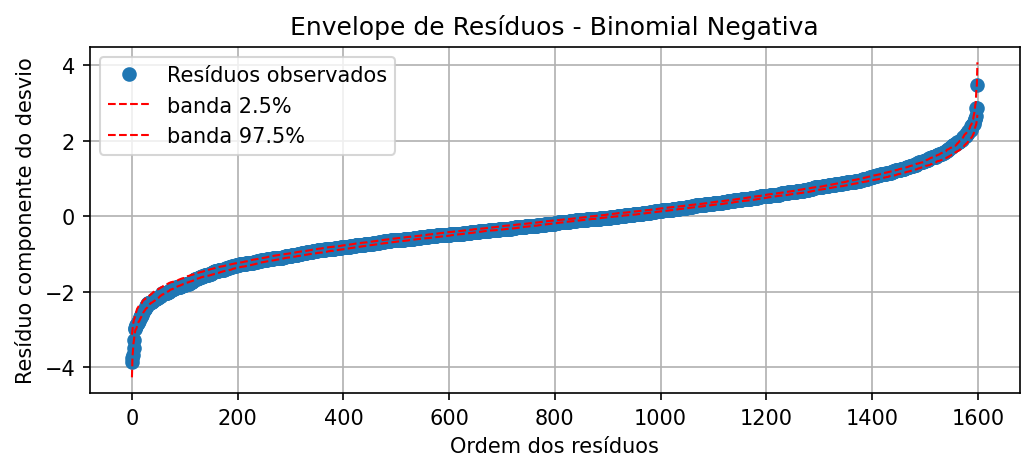

In [49]:
results_nb = ajuste_nb

plt.figure(figsize=(8, 3), dpi=150)
envelope_negbin(results_nb, "Envelope de Resíduos - Binomial Negativa")

O gráfico de resíduos componente do desvio do modelo Binomial Negativa mostra uma melhoria drástica em comparação com o modelo de Poisson:
*   A grande maioria dos resíduos agora está concentrada entre aproximadamente $-3$ e $+3$.
*   A superdispersão observada no modelo de Poisson foi corrigida. Os resíduos agora se distribuem de forma muito mais uniforme e aleatória em torno da linha zero, o que é o comportamento esperado para um modelo bem ajustado.


## **5.**
Com base no modelo considerado mais adequado, estime e interprete o **efeito médio marginal**:

* do consumo de álcool (**alcohol**) sobre o número médio de espirros,
* do uso de anti-histamínico (**antihist**).


In [50]:
emm = ajuste_nb.get_margeff(at='overall', dummy=True)
print(emm.summary())

         GLM Marginal Effects        
Dep. Variable:                nsneeze
Method:                          dydx
At:                           overall
                      dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
C(alcohol)[T.1]     18.7984      1.245     15.094      0.000      16.357      21.239
C(antihist)[T.1]   -19.5758      1.087    -18.012      0.000     -21.706     -17.446
C(smoker)[T.1]      25.0441      1.880     13.320      0.000      21.359      28.729
age                 -0.4666      0.049     -9.611      0.000      -0.562      -0.371
pollen               1.3291      0.046     28.849      0.000       1.239       1.419


O consumo de álcool está associado a um aumento médio de aproximadamente $18.80$ espirros diários na taxa esperada de espirros, em comparação com o não consumo, quando avaliado em média para todos os indivíduos da amostra. Isso significa que, se todos os participantes passassem a consumir álcool nas 24 horas anteriores à observação, a taxa média de espirros em toda a amostra aumentaria em $18.80$.


O uso de anti-histamínico está associado a uma redução média de aproximadamente $19.57$ espirros diários na taxa esperada de espirros, em comparação com o não uso, em média para todos os indivíduos da amostra. Este resultado está alinhado com a expectativa clínica, mostrando que o uso de anti-histamínicos é o fator que mais contribui para redução do número esperado de espirros.

## **6.**
Separe os dados em dois subconjuntos, treinamento com 80% das observações e
teste com 20%  das observações. Com base apenas no conjunto de treinamento, ajuste os modelos Poisson e Binomial Negativo com a mesma estrutura de covariáveis dos itens anteriores. No conjunto de teste, calcule, para cada modelo:

* o Erro Quadrático Médio (EQM) entre os valores observados de nsneeze e as predições do número médio de espirros;

* o Erro Absoluto Médio (EAM).

Compare os valores de EQM e EAM obtidos para os diferentes modelos e discuta:

qual deles apresenta melhor desempenho preditivo fora da amostra;

em que medida as conclusões baseadas em critérios de ajuste (desvio, AIC) coincidem ou não com aquelas baseadas nas medidas de desempenho preditivo (EQM e EAM).



In [51]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Separa dados em treino (80%) e teste (20%)
X = df.drop(columns=['nsneeze'])
y = df['nsneeze']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123456
)

In [52]:
# Combina X_train e y_train para o fit do modelo
df_train = pd.concat([X_train, y_train], axis=1)

formula = "nsneeze ~ C(alcohol) + C(antihist) + C(smoker) + age + pollen"

# Poisson
poisson_model_train = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.Poisson()
).fit()

# Binomial Negativa
nb_model_train = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.NegativeBinomial(alpha=0.2)
).fit()

# Predição

# Poisson
y_pred_poisson = poisson_model_train.predict(X_test)

# Binomial Negative
y_pred_nb = nb_model_train.predict(X_test)

# Calculo das métricas

# Poisson
mse_poisson = mean_squared_error(y_test, y_pred_poisson)
mae_poisson = mean_absolute_error(y_test, y_pred_poisson)

# Binomial Negativa
mse_nb = mean_squared_error(y_test, y_pred_nb)
mae_nb = mean_absolute_error(y_test, y_pred_nb)

# Tabela de resultados
performance_metrics = pd.DataFrame({
    'Modelo': ['Poisson', 'Binomial Negativo'],
    'EQM (Erro Quadrático Médio)': [mse_poisson, mse_nb],
    'EAM (Erro Absoluto Médio)': [mae_poisson, mae_nb]
})


print("\n--- Desempenho Preditivo no Conjunto de Teste ---")
print(performance_metrics.to_string(index=False))


--- Desempenho Preditivo no Conjunto de Teste ---
           Modelo  EQM (Erro Quadrático Médio)  EAM (Erro Absoluto Médio)
          Poisson                  1482.293792                  16.160848
Binomial Negativo                  1752.685160                  16.318820


As conclusões **não coincidem**. O modelo com melhor ajuste estatístico (Binomial Negativa) teve um desempenho preditivo ligeiramente pior, e o modelo estatisticamente inadequado (Poisson) teve um desempenho preditivo marginalmente melhor.

O erro da predição está muito relacionado aos outliers presentes no conjunto de teste. O modelo de Poisson, devido à sua estrutura rígida, pode ter ocorrido de predizer valores de que ficaram, por sorte, mais próximos dessas observações extremas do que os valores preditos pelo modelo Binomial Negativo nesta separação específica de dados. Com a remoção de outliers, provavelmente a Binomial Negativa teria um desempenho superior à Poisson.

## **7.**
Utilizando o modelo escolhido por você, faça previsões do número **esperado** de espirros para os seguintes perfis:

1. Indivíduo A:

   * alcohol = 0,
   * antihist = 1,
   * smoker = 0,
   * age = 30 anos,
   * pollen = valor correspondente a um dia de baixa concentração.

2. Indivíduo B:

   * alcohol = 1,
   * antihist = 0,
   * smoker = 1,
   * age = 50 anos,
   * pollen = valor correspondente a um dia de alta concentração.

Tomando os seguintes valores para pollen:
*   Indivíduo A: 4.67 (mínimo do dataset)
*   Indivíduo B: 201.99 (máximo do dataset)

In [53]:
formula_nb = "nsneeze ~ C(alcohol) + C(antihist) + C(smoker) + age + pollen"

# Ajuste do Modelo Binomial Negativo no conjunto completo de dados
nb_model_full = smf.glm(
    formula=formula_nb,
    data=df,
    family=sm.families.NegativeBinomial(alpha=0.2)
).fit()

# Cria um DataFrame com os perfis para previsão
new_data = pd.DataFrame({
    'alcohol': [0, 1],
    'antihist': [1, 0],
    'smoker': [0, 1],
    'age': [30, 50],
    'pollen': [4.67, 201.99]
})

# É crucial que as variáveis categóricas sejam do tipo esperado pelo modelo.
new_data['alcohol'] = new_data['alcohol'].astype('category')
new_data['antihist'] = new_data['antihist'].astype('category')
new_data['smoker'] = new_data['smoker'].astype('category')

# Faz as previsões
predictions = nb_model_full.predict(new_data)

# Crie uma tabela de resultados
results = pd.DataFrame({
    'Perfil': ['Indivíduo A', 'Indivíduo B'],
    'alcohol': new_data['alcohol'],
    'antihist': new_data['antihist'],
    'smoker': new_data['smoker'],
    'age': new_data['age'],
    'pollen': new_data['pollen'],
    'Previsão (Espirros Esperados)': predictions.round(2)
})

print("--- Previsões do Número Esperado de Espirros (Modelo Binomial Negativa) ---")
print(results.to_markdown(index=False))

--- Previsões do Número Esperado de Espirros (Modelo Binomial Negativa) ---
| Perfil      |   alcohol |   antihist |   smoker |   age |   pollen |   Previsão (Espirros Esperados) |
|:------------|----------:|-----------:|---------:|------:|---------:|--------------------------------:|
| Indivíduo A |         0 |          1 |        0 |    30 |     4.67 |                            2.14 |
| Indivíduo B |         1 |          0 |        1 |    50 |   201.99 |                         3139.27 |


### Interpretação
As previsões demonstram o grande impacto combinado das covariáveis no número esperado de espirros, variando de um número muito baixo a um valor extremamente alto.

**Indivíduo A:** Este indivíduo apresenta o perfil de menor risco no contexto da rinite alérgica:
*   Baixíssima concentração de pólen ($\text{pollen} = 4.67$).
*   Uso de anti-histamínico ($\text{antihist} = 1$), que demonstrou reduzir o número médio de espirros.
*   Ausência de fatores agravantes (álcool e tabagismo).

O modelo prevê que, sob essas condições ideais, o número de espirros diários será muito baixo.

**Indivíduo B:** Este indivíduo combina o pior cenário possível para a rinite:
*   Concentração de pólen na máxima observada na amostra ($\text{pollen} = 201.99$).
*   Ausência de tratamento ($\text{antihist} = 0$).
*   Presença de fatores agravantes (álcool e tabagismo), que demonstraram aumentar o número médio de espirros.

O resultado é um número esperado de espirros extremamente alto, refletindo a forte associação positiva do pólen, tabagismo e álcool com a variável resposta, e a falta do efeito protetor do anti-histamínico. Este valor elevado é compatível com os valores extremos (nsneeze máximo $\approx 3897$) observados no dataset original.